<a href="https://colab.research.google.com/github/Karsuman4298/Generative-AI/blob/main/Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Diffusers is HuggingFace Page for Diffusion Models from HuggingFaceHub

In [1]:
!pip install diffusers transformers accelerate

In [2]:
!nvidia-smi


Sat Mar 21 11:26:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install --upgrade ipywidgets nbformat nbconvert
!jupyter nbextension enable --py widgetsnbextension

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [5]:
from google.colab import output
output.enable_custom_widget_manager()


https://huggingface.co/docs/diffusers/index

In [3]:
from diffusers import StableDiffusionPipeline, StableDiffusionXLPipeline
import torch
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
!pip show torch

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [6]:
model1="Yntec/DreamlikeDiffusion"
model2="stabilityai/stable-diffusion-xl-base-1.0"

In [11]:
pipe=StableDiffusionPipeline.from_pretrained(model1,torch_dtype=torch.float16,use_auth_token=True)
pipe.to("cuda")

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Keyword arguments {'use_auth_token': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.0",
  "_name_or_path": "Yntec/DreamlikeDiffusion",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": null,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [12]:
prompt="A cat wearing sunglasses"

In [13]:
image=pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

PROMPT: A cat wearing sunglasses


(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

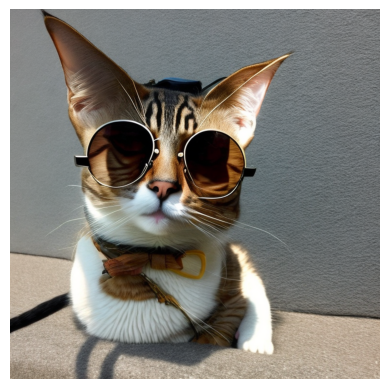

In [14]:
print("PROMPT:",prompt)
plt.imshow(image)
plt.axis("off")

  0%|          | 0/50 [00:00<?, ?it/s]

PROMPT: A girl reading a book under a tree


(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

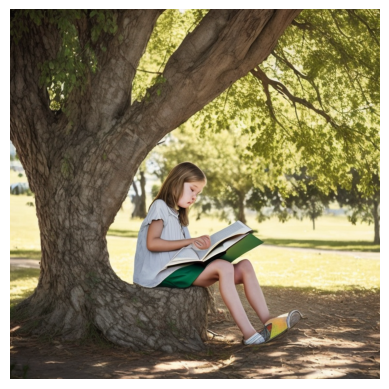

In [15]:
prompt2='A girl reading a book under a tree'
image2=pipe(prompt2).images[0]
print("PROMPT:",prompt2)
plt.imshow(image2)
plt.axis("off")

In [2]:
pipe2=StableDiffusionXLPipeline.from_pretrained(model2,torch_dtype=torch.float16,use_auth_token=True)
pipe2.to("cuda")

NameError: name 'StableDiffusionXLPipeline' is not defined

In [1]:
prompt2='A girl reading a book under a tree'
image3=pipe2(prompt2).images[0]
print("PROMPT:",prompt2)
plt.imshow(image3)
plt.axis("off")

NameError: name 'pipe2' is not defined